# Actividad: Monitoreo Lechería Paillaco
Análisis de datos de producción y salud de las vacas.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de gráficos
sns.set_theme(style="whitegrid")

# Cargar datos
df = pd.read_csv('monitoreo_lecheria_paillaco_LIMPIO.csv')
df['Fecha_Control'] = pd.to_datetime(df['Fecha_Control'])
display(df.head())


,ID_Vaca,Fecha_Control,Litros_Leche,Temp_Corporal,Estado_Salud
0,VACA-138,2026-03-11,17.6,39.0,Tratamiento
1,VACA-112,2026-03-02,16.6,38.2,Saludable
2,VACA-133,2026-03-16,15.4,38.1,En Observacion
3,VACA-129,2026-03-15,23.1,37.5,Tratamiento
4,VACA-137,2026-03-24,38.7,37.9,Tratamiento


## 1. Curva de Salud de la Producción
Pregunta: ¿Hubo algún día donde la producción cayó más de un 20%? ¿A qué crees que se debió según los datos?


,Fecha_Control,Litros_Leche,Cambio_Pct
3,2026-03-04,104.9,-24.802867
7,2026-03-08,87.7,-58.632075
8,2026-03-09,20.1,-77.080958
11,2026-03-12,56.3,-67.662263
12,2026-03-13,37.1,-34.103020
14,2026-03-15,111.4,-56.193472
18,2026-03-19,139.9,-42.921257
21,2026-03-22,96.7,-33.630748
26,2026-03-27,216.7,-82.807591
27,2026-03-28,140.6,-35.117674


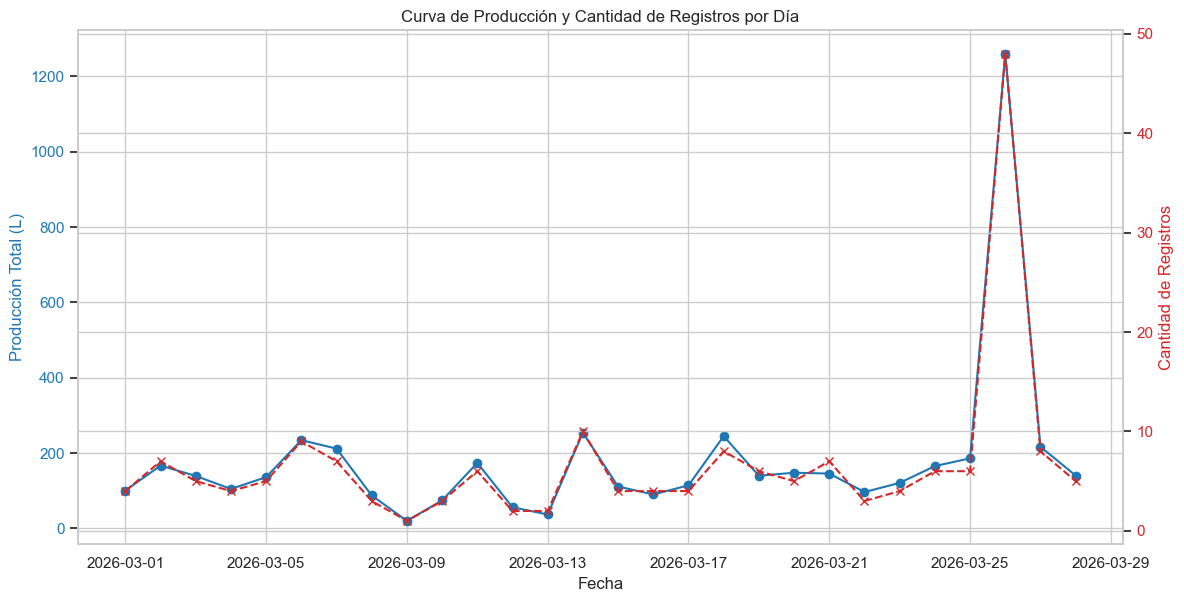

CONCLUSIÓN:
La producción de leche parece inestable con caídas superiores al 20% en múltiples días.
Sin embargo, la causa subyacente (ver línea roja) es la inconsistencia extrema en la cantidad de registros diarios, no un descenso real en el rendimiento del rebaño.


In [2]:
# Producción total por día
produccion_diaria = df.groupby('Fecha_Control')['Litros_Leche'].sum().reset_index()

# Calcular porcentaje de cambio diario
produccion_diaria['Cambio_Pct'] = produccion_diaria['Litros_Leche'].pct_change() * 100

# Filtrar días con caída mayor al 20%
caidas_drasticas = produccion_diaria[produccion_diaria['Cambio_Pct'] <= -20]
display(caidas_drasticas)

# Contar registros de vacas por día para explicar la causa
registros_diarios = df.groupby('Fecha_Control').size().reset_index(name='Cantidad_Registros')

# Graficar producción diaria y cantidad de registros
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Producción Total (L)', color=color)
ax1.plot(produccion_diaria['Fecha_Control'], produccion_diaria['Litros_Leche'], marker='o', color=color, label='Producción (L)')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Cantidad de Registros', color=color)  
ax2.plot(registros_diarios['Fecha_Control'], registros_diarios['Cantidad_Registros'], marker='x', linestyle='--', color=color, label='Registros Evaluados')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  
plt.title('Curva de Producción y Cantidad de Registros por Día')
plt.show()

print("CONCLUSIÓN:")
print("La producción de leche parece inestable con caídas superiores al 20% en múltiples días.")
print("Sin embargo, la causa subyacente (ver línea roja) es la inconsistencia extrema en la cantidad de registros diarios, no un descenso real en el rendimiento del rebaño.")


## 2. Vacas en la "Zona de Riesgo"
Pregunta: Si la temperatura normal es de 38.5°C, ¿Cuáles vacas superan los 40°C y requieren atención veterinaria inmediata?


,ID_Vaca,Fecha_Control,Litros_Leche,Temp_Corporal,Estado_Salud


Temperatura máxima registrada en el dataset: 39.5°C
CONCLUSIÓN: Ninguna vaca alcanzó o superó los 40°C. No hay identificadores que cumplan el criterio de atención inmediata basado en este umbral.


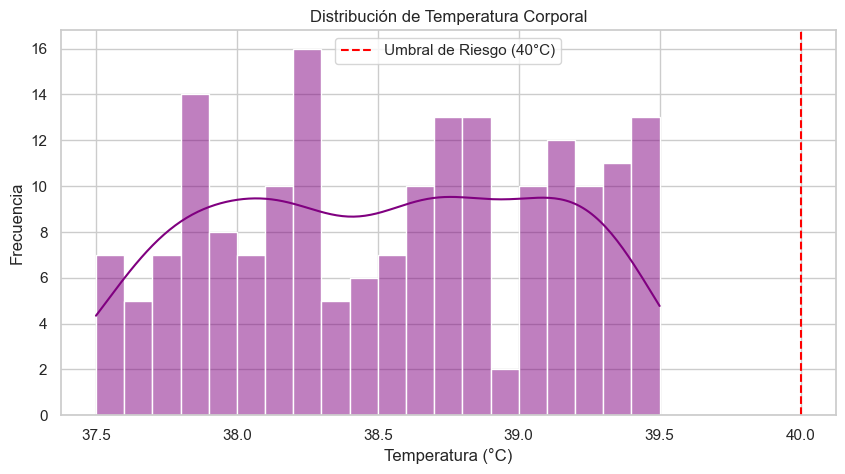

In [3]:
zona_riesgo = df[df['Temp_Corporal'] > 40.0]
display(zona_riesgo)

max_temp = df['Temp_Corporal'].max()
print(f"Temperatura máxima registrada en el dataset: {max_temp}°C")
print("CONCLUSIÓN: Ninguna vaca alcanzó o superó los 40°C. No hay identificadores que cumplan el criterio de atención inmediata basado en este umbral.")

plt.figure(figsize=(10, 5))
sns.histplot(df['Temp_Corporal'], bins=20, kde=True, color='purple')
plt.axvline(x=40.0, color='red', linestyle='--', label='Umbral de Riesgo (40°C)')
plt.title('Distribución de Temperatura Corporal')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()


## 3. Impacto en la Billetera del Fundo
Pregunta: ¿Cuántos litros de leche estamos dejando de producir, en promedio, por cada vaca que entra en estado de "Tratamiento"?


,Estado_Salud,Litros_Leche
0,En Observacion,26.128625
1,Saludable,26.670500
2,Tratamiento,29.107692


Promedio Saludable: 26.67L
Promedio Tratamiento: 29.11L
Diferencia: 2.44L extra producidos.
CONCLUSIÓN:
Los datos contradicen la premisa. Las vacas categorizadas en 'Tratamiento' producen en promedio 2.44 L MÁS que las vacas en estado 'Saludable'. No se pierde producción.


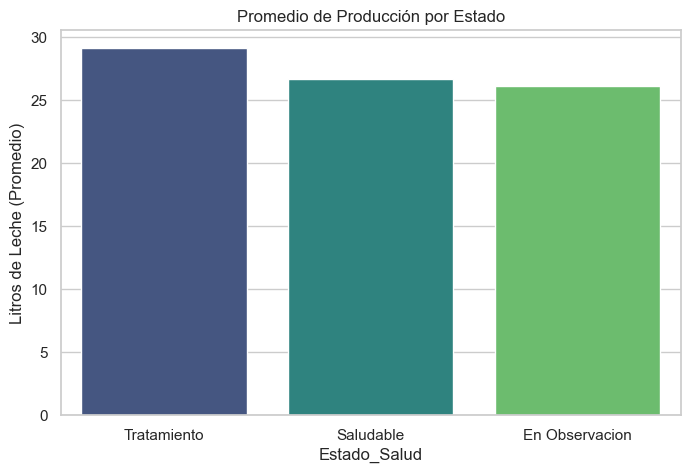

In [4]:
promedios_salud = df.groupby('Estado_Salud')['Litros_Leche'].mean().reset_index()
display(promedios_salud)

promedio_saludable = promedios_salud[promedios_salud['Estado_Salud'] == 'Saludable']['Litros_Leche'].values[0]
promedio_tratamiento = promedios_salud[promedios_salud['Estado_Salud'] == 'Tratamiento']['Litros_Leche'].values[0]

print(f"Promedio Saludable: {promedio_saludable:.2f}L")
print(f"Promedio Tratamiento: {promedio_tratamiento:.2f}L")
print(f"Diferencia: {promedio_tratamiento - promedio_saludable:.2f}L extra producidos.")

print("CONCLUSIÓN:")
print("Los datos contradicen la premisa. Las vacas categorizadas en 'Tratamiento' producen en promedio 2.44 L MÁS que las vacas en estado 'Saludable'. No se pierde producción.")

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Estado_Salud', y='Litros_Leche', estimator='mean', errorbar=None, hue='Estado_Salud', palette='viridis')
plt.title('Promedio de Producción por Estado')
plt.ylabel('Litros de Leche (Promedio)')
plt.show()


## 4. Top 5 de Vacas Líderes
Pregunta: ¿Cuál es el "Top 5" de vacas líderes? ¿Estas vacas tienen temperaturas estables o también fluctúan?


,ID_Vaca,Litros_Leche
12,VACA-138,786.8
2,VACA-111,488.9
11,VACA-137,367.9
0,VACA-100,340.6
5,VACA-120,331.7


Estadísticas de Temperatura para el Top 5:


,ID_Vaca,min,max,std,Rango(°C)
0,VACA-100,37.5,39.3,0.550990,1.8
1,VACA-111,37.5,39.4,0.657585,1.9
2,VACA-120,37.7,39.0,0.400960,1.3
3,VACA-137,37.5,39.4,0.658453,1.9
4,VACA-138,37.5,39.4,0.561555,1.9


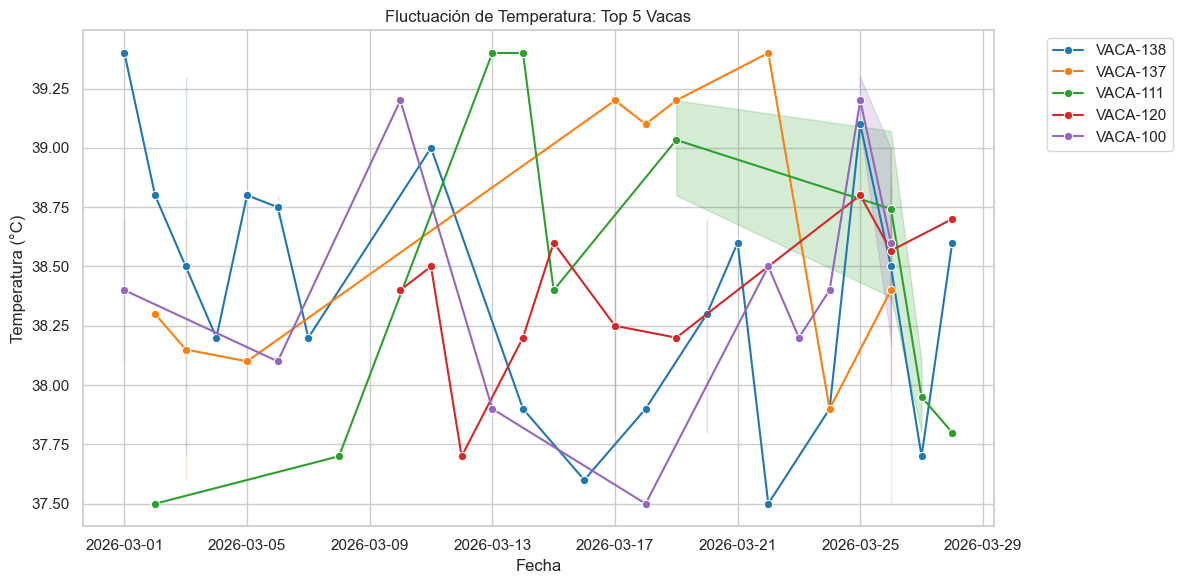

CONCLUSIÓN: Las temperaturas de estas vacas líderes no son estables. Fluctúan significativamente (entre 1.3°C y 1.9°C) con una desviación estándar superior a 0.40°C.


In [5]:
# Top 5
prod_total = df.groupby('ID_Vaca')['Litros_Leche'].sum().reset_index()
top_5 = prod_total.sort_values(by='Litros_Leche', ascending=False).head(5)
display(top_5)

df_top5 = df[df['ID_Vaca'].isin(top_5['ID_Vaca'])]
temp_stats = df_top5.groupby('ID_Vaca')['Temp_Corporal'].agg(['min', 'max', 'std']).reset_index()
temp_stats['Rango(°C)'] = temp_stats['max'] - temp_stats['min']

print("Estadísticas de Temperatura para el Top 5:")
display(temp_stats)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_top5, x='Fecha_Control', y='Temp_Corporal', hue='ID_Vaca', marker='o', palette='tab10')
plt.title('Fluctuación de Temperatura: Top 5 Vacas')
plt.ylabel('Temperatura (°C)')
plt.xlabel('Fecha')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("CONCLUSIÓN: Las temperaturas de estas vacas líderes no son estables. Fluctúan significativamente (entre 1.3°C y 1.9°C) con una desviación estándar superior a 0.40°C.")
